In [1]:
!date

Thu Sep 17 23:54:42 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
outdir = f'{projdir}/results/qc/data/qc18'
figdir = f'{projdir}/figures/pmds'

In [3]:
### donor x 10kb bin methylation (B01b) + bin annotation
z = np.load(f'{projdir}/results/meth_bins/donor_bin_meth_10kb.npz')
meth, donors = z['meth'], z['donors']
bins = pd.read_csv(f'{projdir}/results/meth_bins/bins_index.tsv.gz', sep='\t')
dom = pd.read_csv(f'{projdir}/results/meth_bins/domain_frequency_10kb.tsv.gz', sep='\t', usecols=['chrom', 'bin_start', 'freq_pmd', 'class_pmd'])
rt = pd.read_csv(f'{projdir}/results/meth_bins/annotations/rt_lad_10kb.tsv.gz', sep='\t')
bins = bins.merge(dom, on=['chrom', 'bin_start'], how='left').merge(rt, on=['chrom', 'bin_start'], how='left')
bins.head()

,chrom,bin_start,freq_pmd,class_pmd,rt,lad_bp
0,chr1,690000,0.0,never,68.8771,0.0
1,chr1,700000,0.0,never,68.3749,0.0
2,chr1,710000,0.0,never,67.6994,0.0
3,chr1,720000,0.0,never,66.9052,0.0
4,chr1,730000,0.0,never,66.0378,0.0


In [4]:
meth.shape, bins.shape

((201, 265052), (265052, 6))

In [5]:
### donor covariates: domain depth + chemistry (the two things to remove before calling a bin 'spatially variable')
m = pd.read_csv(f'{projdir}/results/qc/data/qc13/donor_pmd_expansion_metrics.tsv', sep='\t').set_index('sample').reindex(donors)
m[['depth_constitutive', 'chemistry', 'superpopulation', 'sex']].head()

,depth_constitutive,chemistry,superpopulation,sex
sample,,,,
HG00097,0.245584,R1041,EUR,female
HG00099,0.197980,R941,EUR,female
HG00126,0.188286,R1041,EUR,male
HG00128,0.236361,R1041,EUR,female
HG00133,0.201178,R1041,EUR,female


In [6]:
### framing 1 -- which bins vary beyond global depth: per-bin OLS on [1, depth, chemistry], residual variance
keep = np.isfinite(meth).mean(0) >= 0.95
Y = meth[:, keep].astype(np.float64)
Y = np.where(np.isfinite(Y), Y, np.nanmean(Y, 0))
X = np.column_stack([np.ones(len(donors)), m.depth_constitutive.values, (m.chemistry == 'R1041').astype(float).values])
B = np.linalg.lstsq(X, Y, rcond=None)[0]
R = Y - X @ B
tot_var = Y.var(0)
res_var = R.var(0)
bv = bins[keep].copy()
bv['total_var'], bv['resid_var'], bv['frac_explained'] = tot_var, res_var, 1 - res_var / tot_var
bv['depth_slope'] = B[1]
bv.groupby('class_pmd')[['total_var', 'resid_var', 'frac_explained', 'depth_slope']].median()

,total_var,resid_var,frac_explained,depth_slope
class_pmd,,,,
common,0.004009,0.000581,0.847012,-1.210559
constitutive,0.004704,0.000458,0.902291,-1.367704
never,0.000660,0.000343,0.328100,-0.221306
rare,0.002964,0.000608,0.756123,-0.964124
variable,0.003772,0.000582,0.831498,-1.156488


In [7]:
### residual variance by replication-timing decile -- is spatial variability a late-replication property too?
bv['rt_decile'] = pd.qcut(bv.rt, 10, labels=False, duplicates='drop') + 1
bv.groupby('rt_decile')[['total_var', 'resid_var', 'frac_explained']].median()

,total_var,resid_var,frac_explained
rt_decile,,,
1.0,0.005046,0.000415,0.916880
2.0,0.004831,0.000451,0.905977
3.0,0.004544,0.000485,0.891341
4.0,0.004126,0.000506,0.867008
5.0,0.003727,0.000515,0.832122
6.0,0.003153,0.000518,0.773344
7.0,0.002406,0.000500,0.680400
8.0,0.001777,0.000479,0.583561
9.0,0.001143,0.000436,0.465790


In [8]:
### framing 3 -- length scale: autocorrelation of each donor's residual track along the genome (lags in 10kb bins)
lags = [1, 2, 5, 10, 20, 50, 100, 200]
chrom_of = bv.chrom.values
ac = np.zeros((len(donors), len(lags)))
for i in range(len(donors)):
    r = R[i]
    num = np.zeros(len(lags)); den = 0.0
    for c in np.unique(chrom_of):
        x = r[chrom_of == c]; x = x - x.mean()
        den += (x * x).sum()
        for j, L in enumerate(lags):
            if len(x) > L:
                num[j] += (x[:-L] * x[L:]).sum()
    ac[i] = num / den
acf = pd.DataFrame(ac, index=donors, columns=[f'lag_{L * 10}kb' for L in lags])
acf.describe().loc[['mean', '25%', '50%', '75%']].round(3)

,lag_10kb,lag_20kb,lag_50kb,lag_100kb,lag_200kb,lag_500kb,lag_1000kb,lag_2000kb
mean,0.506,0.437,0.328,0.235,0.151,0.066,0.028,0.010
25%,0.452,0.392,0.281,0.193,0.120,0.050,0.020,0.005
50%,0.498,0.427,0.317,0.220,0.141,0.063,0.025,0.010
75%,0.563,0.493,0.367,0.268,0.177,0.078,0.034,0.014


In [9]:
### same after shuffling bins within chromosome (null: no spatial structure)
rng = np.random.RandomState(1)
i = 0
x = R[i].copy()
for c in np.unique(chrom_of):
    s = chrom_of == c
    x[s] = rng.permutation(x[s])
nul = []
for L in lags:
    num, den = 0.0, 0.0
    for c in np.unique(chrom_of):
        y = x[chrom_of == c]; y = y - y.mean()
        den += (y * y).sum(); num += (y[:-L] * y[L:]).sum()
    nul.append(num / den)
pd.Series(nul, index=acf.columns).round(3)

lag_10kb      0.002
lag_20kb      0.001
lag_50kb      0.003
lag_100kb    -0.003
lag_200kb     0.001
lag_500kb     0.001
lag_1000kb   -0.002
lag_2000kb   -0.002
dtype: float64

In [10]:
### framing 4 -- donor structure in WHICH domains are deep: PCA of residuals over domain bins only
dm = bv.class_pmd.isin(['constitutive', 'variable', 'common']).values
Rd = R[:, dm] - R[:, dm].mean(0)
u, s, vt = np.linalg.svd(Rd, full_matrices=False)
ve = s ** 2 / (s ** 2).sum()
pcs = pd.DataFrame(u[:, :10] * s[:10], index=donors, columns=[f'rPC{k + 1}' for k in range(10)])
pd.Series(ve[:10], index=pcs.columns).round(3)

rPC1     0.204
rPC2     0.078
rPC3     0.034
rPC4     0.025
rPC5     0.021
rPC6     0.016
rPC7     0.015
rPC8     0.014
rPC9     0.011
rPC10    0.011
dtype: float64

In [11]:
### do the residual domain-shape PCs track anything?
cv = m[['chemistry', 'superpopulation', 'sex', 'passage', 'established', 'hprc2_meth_qc_flag', 'depth_constitutive']].join(pcs)
xist = pd.read_csv(f'{projdir}/results/qc/data/xist_promoter_skew.tsv', sep='\t').set_index('sample')['skew']
cv['xist_skew'] = xist.reindex(cv.index)
rows = []
for p in pcs.columns[:5]:
    for c in ['chemistry', 'superpopulation', 'sex', 'passage', 'established', 'hprc2_meth_qc_flag', 'xist_skew']:
        sub = cv[[p, c]].dropna()
        term = c if c in ('passage', 'xist_skew') else f'C({c})'
        f = smf.ols(f'{p} ~ {term}', sub).fit()
        rows.append({'pc': p, 'covariate': c, 'n': len(sub), 'r2': f.rsquared, 'p': f.f_pvalue})
pc_assoc = pd.DataFrame(rows)
pc_assoc.pivot(index='covariate', columns='pc', values='r2').round(3)

pc,rPC1,rPC2,rPC3,rPC4,rPC5
covariate,,,,,
chemistry,0.000,0.000,-0.000,0.000,0.000
established,0.026,0.023,0.066,0.001,0.043
hprc2_meth_qc_flag,0.004,0.004,0.060,0.179,0.000
passage,0.000,0.001,0.001,0.017,0.008
sex,0.011,0.001,0.035,0.004,0.012
superpopulation,0.037,0.059,0.072,0.022,0.331
xist_skew,0.000,0.004,0.035,0.000,0.044


In [12]:
pc_assoc.pivot(index='covariate', columns='pc', values='p').applymap(lambda v: f'{v:.1e}')

pc,rPC1,rPC2,rPC3,rPC4,rPC5
covariate,,,,,
chemistry,1.0e+00,1.0e+00,1.0e+00,1.0e+00,1.0e+00
established,4.3e-02,6.0e-02,1.2e-03,7.1e-01,9.7e-03
hprc2_meth_qc_flag,4.0e-01,3.9e-01,4.8e-04,4.0e-10,8.9e-01
passage,1.0e+00,7.0e-01,7.0e-01,1.0e-01,2.6e-01
sex,1.6e-01,7.0e-01,9.9e-03,4.2e-01,1.4e-01
superpopulation,1.3e-01,2.0e-02,6.3e-03,3.7e-01,5.7e-16
xist_skew,8.4e-01,5.6e-01,6.8e-02,9.0e-01,3.9e-02


In [13]:
### framing 6 -- within-domain position: metagene (A01f) over constitutive domains >= 300 kb, 20 flank + 40 body + 20 flank bins
files = sorted(glob.glob(f'{projdir}/results/pmd_metagene/per_hap/*.npz'))
prof = {}
for f in files:
    tag = f.split('/')[-1][:-4]
    s = tag.rsplit('_hap', 1)[0]
    a = np.load(f)['lcl_constitutive_ge300kb'].astype(np.float32)
    prof.setdefault(s, []).append(a)
mg_samples = [s for s in donors if s in prof]
mg = np.stack([np.nanmean(np.stack(prof[s]), 0) for s in mg_samples])     # donor x domain x position
mg.shape

/u/home/t/terencew/project-cluo/miniconda3/envs/allcools/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: Mean of empty slice
  # Remove the CWD from sys.path while we load stuff.


(201, 621, 80)

In [14]:
### per position: between-donor variance, and the variance left after removing donor depth + chemistry (averaged over domains)
Xm = np.column_stack([np.ones(len(mg_samples)), m.loc[mg_samples, 'depth_constitutive'].values,
                      (m.loc[mg_samples, 'chemistry'] == 'R1041').astype(float).values])
n_dom, n_pos = mg.shape[1], mg.shape[2]
tv = np.full((n_dom, n_pos), np.nan); rv = np.full((n_dom, n_pos), np.nan); sl = np.full((n_dom, n_pos), np.nan)
for k in range(n_pos):
    Yk = mg[:, :, k]
    ok = np.isfinite(Yk).mean(0) >= 0.9
    Yk = np.where(np.isfinite(Yk), Yk, np.nanmean(Yk, 0))[:, ok]
    b = np.linalg.lstsq(Xm, Yk, rcond=None)[0]
    tv[ok, k], rv[ok, k], sl[ok, k] = Yk.var(0), (Yk - Xm @ b).var(0), b[1]
pos = np.r_[np.linspace(-200, 0, 21)[:-1] + 5, np.linspace(0, 100, 41)[:-1] + 1.25, np.linspace(100, 300, 21)[:-1] + 5]
prof_df = pd.DataFrame({'position': np.arange(n_pos), 'region': ['left_flank'] * 20 + ['body'] * 40 + ['right_flank'] * 20,
                        'total_var': np.nanmedian(tv, 0), 'resid_var': np.nanmedian(rv, 0), 'depth_slope': np.nanmedian(sl, 0),
                        'mean_meth': np.nanmean(mg, (0, 1))})
prof_df.iloc[[0, 10, 19, 20, 22, 25, 30, 40, 50, 55, 57, 59, 60, 70, 79]].round(4)

/u/home/t/terencew/project-cluo/miniconda3/envs/allcools/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: Mean of empty slice
  if __name__ == '__main__':


,position,region,total_var,resid_var,depth_slope,mean_meth
0,0,left_flank,21.4501,5.2728,-66.1954,72.087898
10,10,left_flank,20.0356,5.4948,-63.5943,72.264603
19,19,left_flank,20.9590,6.6372,-74.7639,71.516899
20,20,body,31.2853,4.7882,-107.4737,62.230900
22,22,body,40.5540,3.7746,-127.9505,58.420601
25,25,body,42.1940,3.4230,-131.7985,57.508499
30,30,body,44.6911,3.2762,-135.5350,56.595798
40,40,body,45.1519,3.2553,-135.5862,55.749802
50,50,body,44.4221,3.2370,-135.2129,56.185799
55,55,body,42.4181,3.4817,-130.9931,57.231300


In [15]:
### edges vs core of the body: first/last 5 body bins (12.5% of the domain each side) vs central 20
body = prof_df[prof_df.region == 'body'].reset_index(drop=True)
edge = pd.concat([body.iloc[:5], body.iloc[-5:]])
core = body.iloc[10:30]
pd.DataFrame({'edge': edge[['total_var', 'resid_var', 'depth_slope', 'mean_meth']].mean(),
              'core': core[['total_var', 'resid_var', 'depth_slope', 'mean_meth']].mean()}).round(4)

,edge,core
total_var,38.7311,44.8516
resid_var,3.9083,3.1899
depth_slope,-123.4725,-136.0569
mean_meth,59.1820,56.0160


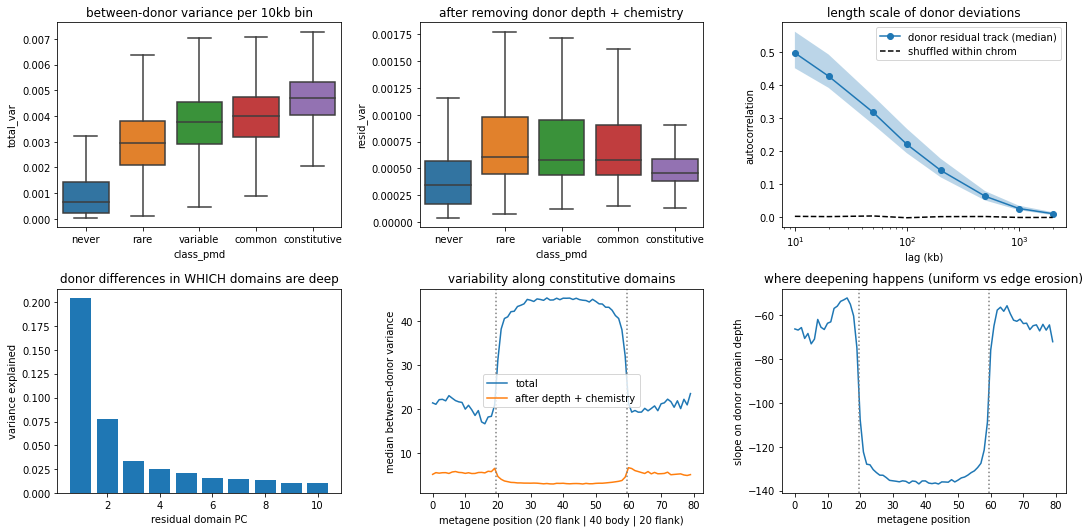

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
cls = ['never', 'rare', 'variable', 'common', 'constitutive']
sns.boxplot(data=bv, x='class_pmd', y='total_var', order=cls, showfliers=False, ax=axes[0, 0]); axes[0, 0].set_title('between-donor variance per 10kb bin')
sns.boxplot(data=bv, x='class_pmd', y='resid_var', order=cls, showfliers=False, ax=axes[0, 1]); axes[0, 1].set_title('after removing donor depth + chemistry')
axes[0, 2].plot([L * 10 for L in lags], acf.median(), 'o-', label='donor residual track (median)')
axes[0, 2].fill_between([L * 10 for L in lags], acf.quantile(0.25), acf.quantile(0.75), alpha=0.3)
axes[0, 2].plot([L * 10 for L in lags], nul, 'k--', label='shuffled within chrom')
axes[0, 2].set_xscale('log'); axes[0, 2].set_xlabel('lag (kb)'); axes[0, 2].set_ylabel('autocorrelation'); axes[0, 2].legend(); axes[0, 2].set_title('length scale of donor deviations')
axes[1, 0].bar(range(1, 11), ve[:10]); axes[1, 0].set_xlabel('residual domain PC'); axes[1, 0].set_ylabel('variance explained'); axes[1, 0].set_title('donor differences in WHICH domains are deep')
axes[1, 1].plot(prof_df.position, prof_df.total_var, label='total'); axes[1, 1].plot(prof_df.position, prof_df.resid_var, label='after depth + chemistry')
for x in (19.5, 59.5): axes[1, 1].axvline(x, color='grey', ls=':')
axes[1, 1].set_xlabel('metagene position (20 flank | 40 body | 20 flank)'); axes[1, 1].set_ylabel('median between-donor variance'); axes[1, 1].legend(); axes[1, 1].set_title('variability along constitutive domains')
axes[1, 2].plot(prof_df.position, prof_df.depth_slope)
for x in (19.5, 59.5): axes[1, 2].axvline(x, color='grey', ls=':')
axes[1, 2].set_xlabel('metagene position'); axes[1, 2].set_ylabel('slope on donor domain depth'); axes[1, 2].set_title('where deepening happens (uniform vs edge erosion)')
plt.tight_layout()
plt.savefig(f'{figdir}/qc18_spatial_heterogeneity.png', dpi=150)

In [17]:
bv.drop(columns=['rt_decile']).to_csv(f'{outdir}/bin_residual_variance_10kb.tsv.gz', sep='\t', index=False, float_format='%.5g')
acf.to_csv(f'{outdir}/donor_residual_autocorrelation.tsv', sep='\t', float_format='%.4g')
pcs.to_csv(f'{outdir}/residual_domain_pcs.tsv', sep='\t', float_format='%.5g')
pc_assoc.to_csv(f'{outdir}/residual_domain_pcs_vs_covariates.tsv', sep='\t', index=False)
prof_df.to_csv(f'{outdir}/metagene_position_variance.tsv', sep='\t', index=False, float_format='%.5g')

In [18]:
!date

Thu Sep 17 23:56:29 PDT 2026
